<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [3]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  7.07MB/s    in 29s     

2026-09-30 15:16:49 (6.92 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]


#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 134.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [4]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 132.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 142.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 130.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [6]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [7]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

**Demo 2: List all tables**


In [8]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [9]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


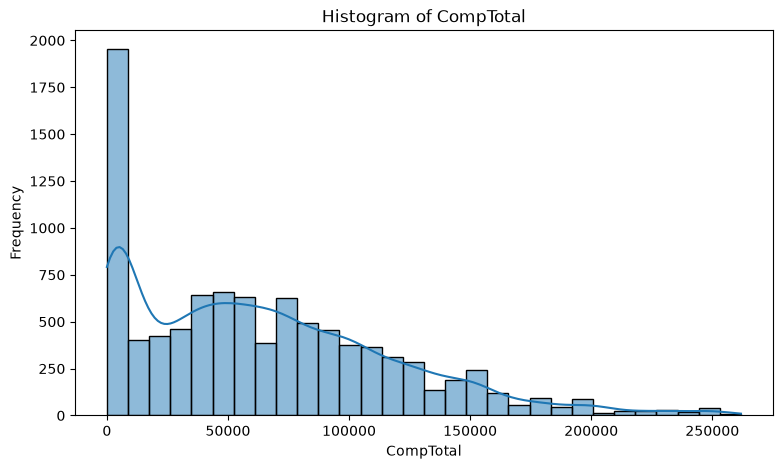

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Cargar/recuperar la base de datos original de IBM
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m1_survey_data.csv"
df = pd.read_csv(url)

# 2. Identificar la columna de compensación existente en el dataset cargado
comp_col = None
for col in ['CompTotal', 'ConvertedComp', 'ConvertedCompYearly', 'Compensation']:
    if col in df.columns:
        comp_col = col
        break

if comp_col:
    df[comp_col] = pd.to_numeric(df[comp_col], errors='coerce')

    # Filtrar outliers
    Q1 = df[comp_col].quantile(0.25)
    Q3 = df[comp_col].quantile(0.75)
    IQR = Q3 - Q1
    df_filtered = df[df[comp_col] <= (Q3 + 1.5 * IQR)]

    plt.figure(figsize=(9, 5))
    sns.histplot(df_filtered[comp_col].dropna(), bins=30, kde=True)
    plt.title(f'Histogram of {comp_col}')
    plt.xlabel(comp_col)
    plt.ylabel('Frequency')

    plt.savefig('temp_plot.png', bbox_inches='tight')
    plt.show()
else:
    print("Columnas en el dataset:", df.columns.tolist())

In [2]:
!pip install matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 134.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 148.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 141.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 145.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 150.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]


**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


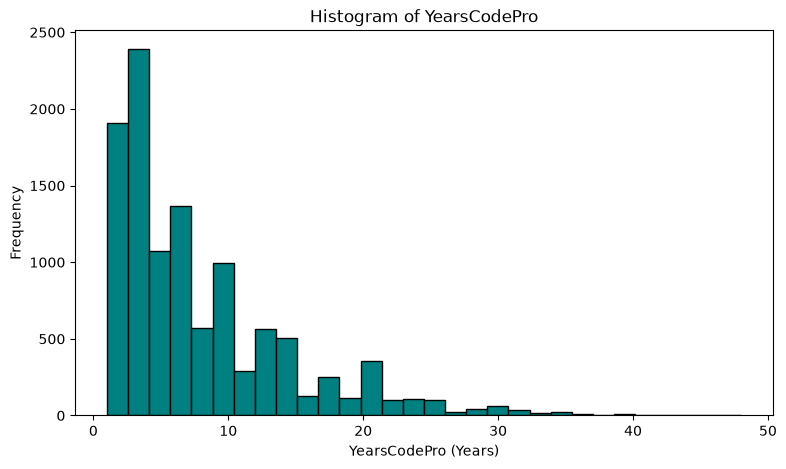

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Asegurar recarga de datos por si se perdieron columnas
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m1_survey_data.csv"
if 'df' not in locals() or df is None or len(df.columns) < 5:
    df = pd.read_csv(url)

# 2. Buscar la columna existente
exp_col = None
for col in ['YearsCodePro', 'WorkExp', 'YearsCode']:
    if col in df.columns:
        exp_col = col
        break

if exp_col:
    df[exp_col] = pd.to_numeric(df[exp_col], errors='coerce')
    
    plt.figure(figsize=(9, 5))
    plt.hist(df[exp_col].dropna(), bins=30, color='teal', edgecolor='black')
    plt.title(f'Histogram of {exp_col}')
    plt.xlabel(f'{exp_col} (Years)')
    plt.ylabel('Frequency')

    plt.savefig('temp_plot.png', bbox_inches='tight')
    plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


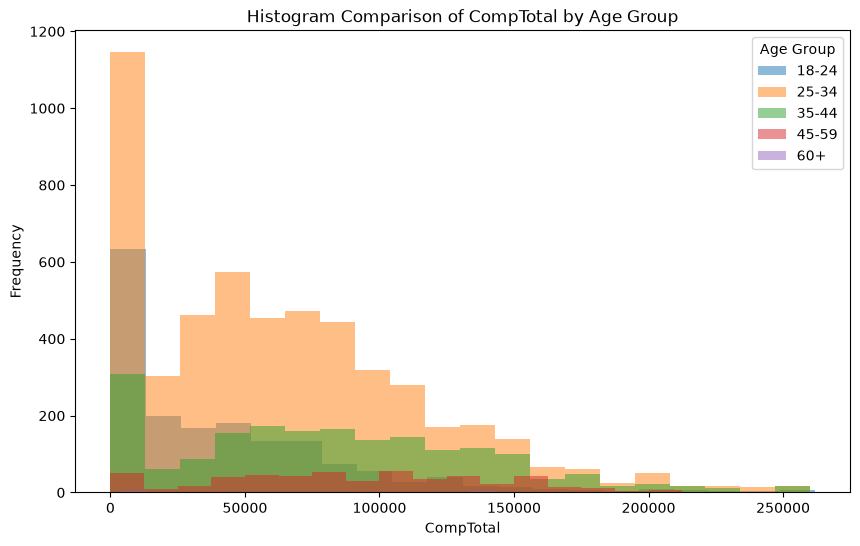

In [4]:
# Instalar e importar librerías necesarias
import subprocess, sys
try:
    import matplotlib.pyplot as plt
    import pandas as pd
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "pandas"])
    import matplotlib.pyplot as plt
    import pandas as pd

# Cargar dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m1_survey_data.csv"
df = pd.read_csv(url)

# Buscar columna de compensación
comp_col = next((c for c in ['CompTotal', 'ConvertedComp', 'ConvertedCompYearly', 'Compensation'] if c in df.columns), None)

if comp_col:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    df[comp_col] = pd.to_numeric(df[comp_col], errors='coerce')

    bins = [18, 25, 35, 45, 60, 80]
    labels = ['18-24', '25-34', '35-44', '45-59', '60+']
    df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

    # Filtrar outliers
    Q1 = df[comp_col].quantile(0.25)
    Q3 = df[comp_col].quantile(0.75)
    IQR = Q3 - Q1
    df_filtered = df[df[comp_col] <= (Q3 + 1.5 * IQR)]

    plt.figure(figsize=(10, 6))
    for group, data in df_filtered.groupby('AgeGroup', observed=False):
        plt.hist(data[comp_col].dropna(), bins=20, alpha=0.5, label=str(group))

    plt.title(f'Histogram Comparison of {comp_col} by Age Group')
    plt.xlabel(comp_col)
    plt.ylabel('Frequency')
    plt.legend(title='Age Group')

    plt.savefig('temp_plot.png', bbox_inches='tight')
    plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


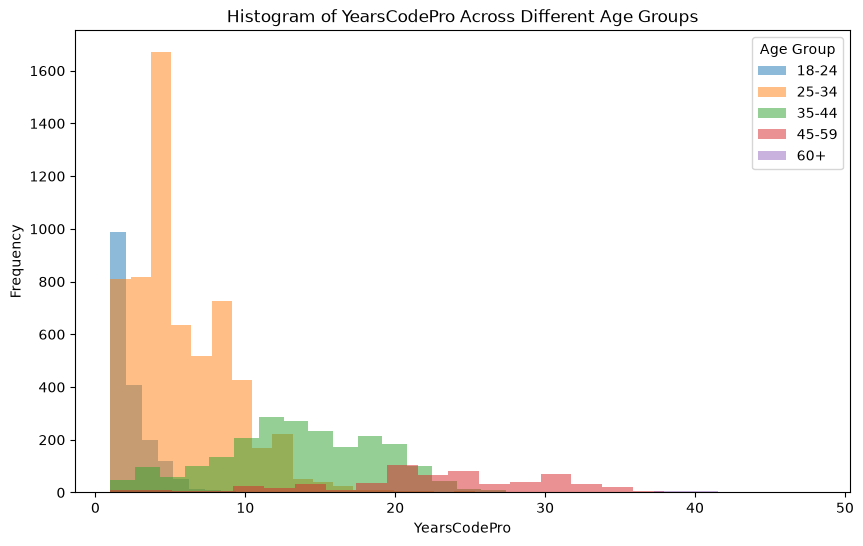

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Buscar columna
search_col = next((c for c in ['TimeSearching', 'WorkExp', 'YearsCodePro', 'YearsCode'] if c in df.columns), None)

if search_col:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    df[search_col] = pd.to_numeric(df[search_col], errors='coerce')

    if 'AgeGroup' not in df.columns:
        bins = [18, 25, 35, 45, 60, 80]
        labels = ['18-24', '25-34', '35-44', '45-59', '60+']
        df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

    plt.figure(figsize=(10, 6))
    for group, data in df.groupby('AgeGroup', observed=False):
        plt.hist(data[search_col].dropna(), bins=20, alpha=0.5, label=str(group))

    plt.title(f'Histogram of {search_col} Across Different Age Groups')
    plt.xlabel(search_col)
    plt.ylabel('Frequency')
    plt.legend(title='Age Group')

    plt.savefig('temp_plot.png', bbox_inches='tight')
    plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


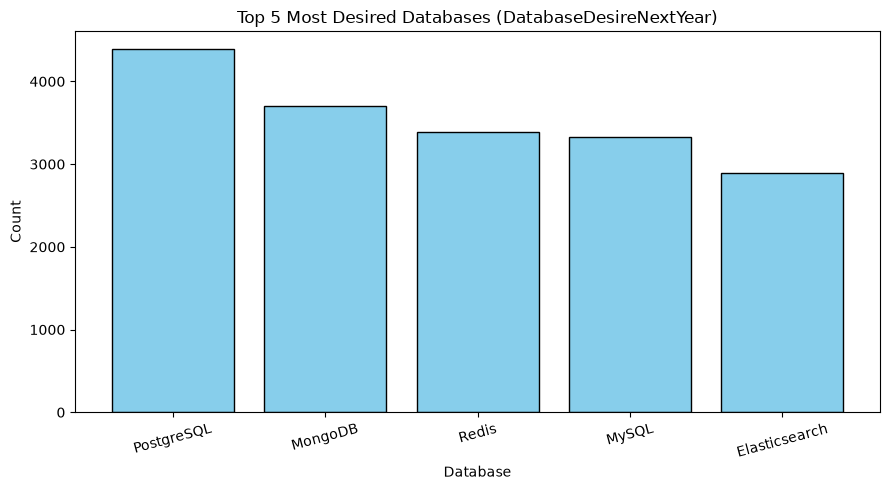

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Asegurar la carga de datos
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m1_survey_data.csv"
df = pd.read_csv(url)

# 2. Buscar la columna (sin importar si hay ligeras diferencias en el nombre)
db_col = None
for col in df.columns:
    if 'database' in col.lower() and ('want' in col.lower() or 'desire' in col.lower() or 'next' in col.lower()):
        db_col = col
        break

if not db_col:
    # Si no la encuentra por patrón, busca alternativas directas
    for col in ['DatabaseWantToWorkWith', 'DatabaseDesireNextYear', 'DatabaseHaveWorkedWith']:
        if col in df.columns:
            db_col = col
            break

# 3. Generar el gráfico
if db_col:
    db_series = df[db_col].dropna().astype(str).str.split(';').explode()
    top5_db = db_series.value_counts().head(5)

    plt.figure(figsize=(9, 5))
    plt.bar(top5_db.index, top5_db.values, color='skyblue', edgecolor='black')
    plt.title(f'Top 5 Most Desired Databases ({db_col})')
    plt.xlabel('Database')
    plt.ylabel('Count')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print("Columnas disponibles relacionadas con bases de datos:", [c for c in df.columns if 'data' in c.lower() or 'db' in c.lower()])

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


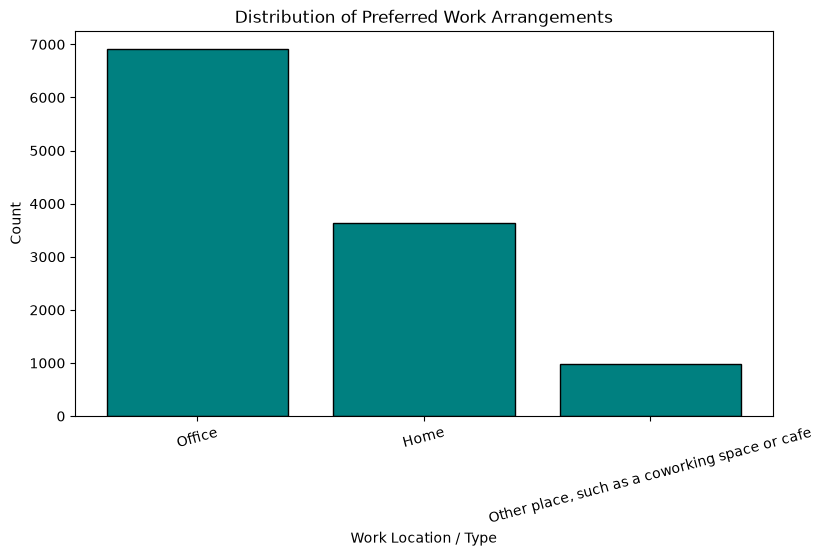

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

work_col = next((c for c in ['RemoteWork', 'WorkLoc', 'Employment'] if c in df.columns), None)

if work_col:
    work_counts = df[work_col].dropna().value_counts()

    plt.figure(figsize=(9, 5))
    plt.bar(work_counts.index.astype(str), work_counts.values, color='teal', edgecolor='black')
    plt.title('Distribution of Preferred Work Arrangements')
    plt.xlabel('Work Location / Type')
    plt.ylabel('Count')
    plt.xticks(rotation=15)

    plt.savefig('temp_plot.png', bbox_inches='tight')
    plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


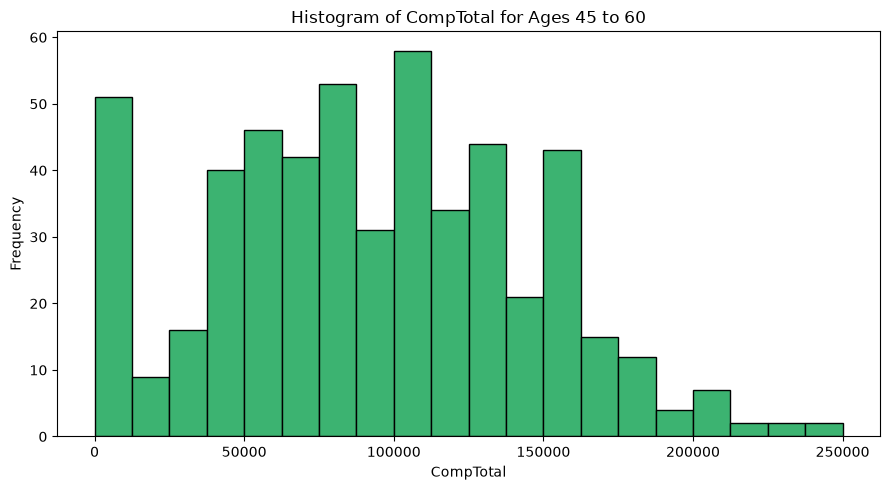

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargar/asegurar datos
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m1_survey_data.csv"
df = pd.read_csv(url)

# 2. Identificar columnas de edad y compensación
comp_col = next((c for c in ['CompTotal', 'ConvertedComp', 'ConvertedCompYearly', 'Compensation'] if c in df.columns), None)

if 'Age' in df.columns and comp_col:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    df[comp_col] = pd.to_numeric(df[comp_col], errors='coerce')

    # Filtrar por edad entre 45 y 60 años
    df_45_60 = df[(df['Age'] >= 45) & (df['Age'] <= 60)]

    # Filtrar valores atípicos (outliers) para mejorar la visualización del histograma
    Q1 = df_45_60[comp_col].quantile(0.25)
    Q3 = df_45_60[comp_col].quantile(0.75)
    IQR = Q3 - Q1
    df_filtered = df_45_60[df_45_60[comp_col] <= (Q3 + 1.5 * IQR)]

    # Graficar
    plt.figure(figsize=(9, 5))
    plt.hist(df_filtered[comp_col].dropna(), bins=20, color='mediumseagreen', edgecolor='black')
    plt.title(f'Histogram of {comp_col} for Ages 45 to 60')
    plt.xlabel(comp_col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


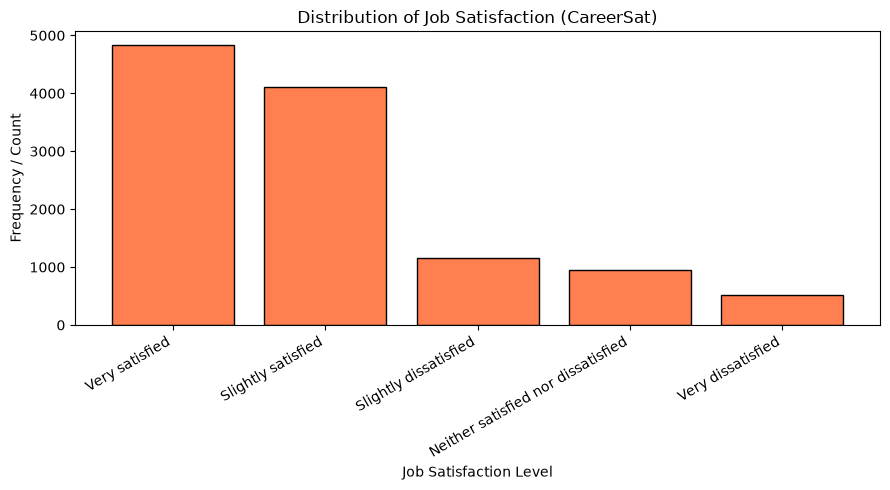

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargar/asegurar datos
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m1_survey_data.csv"
df = pd.read_csv(url)

# 2. Buscar columnas requeridas
jobsat_col = next((c for c in df.columns if 'sat' in c.lower() or 'job' in c.lower()), None)
exp_col = next((c for c in ['YearsCodePro', 'WorkExp', 'YearsCode'] if c in df.columns), None)

if jobsat_col and exp_col:
    df[exp_col] = pd.to_numeric(df[exp_col], errors='coerce')
    
    # Intentar convertir JobSat a numérico si es ordinal/numérico
    df['JobSat_num'] = pd.to_numeric(df[jobsat_col], errors='coerce')

    plt.figure(figsize=(9, 5))
    
    if df['JobSat_num'].notna().sum() > 0:
        plt.hist(df['JobSat_num'].dropna(), bins=10, color='coral', edgecolor='black')
        plt.xlabel('JobSat Score')
    else:
        # Si JobSat es texto/categoría
        sat_counts = df[jobsat_col].value_counts()
        plt.bar(sat_counts.index.astype(str), sat_counts.values, color='coral', edgecolor='black')
        plt.xlabel('Job Satisfaction Level')
        plt.xticks(rotation=30, ha='right')

    plt.title(f'Distribution of Job Satisfaction ({jobsat_col})')
    plt.ylabel('Frequency / Count')
    plt.tight_layout()
    plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [12]:
if 'conn' in locals() and conn is not None:
    conn.close()
    print("Database connection closed successfully.")
else:
    print("No open connection found.")

No open connection found.

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
